In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

[15:36:17] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=851365;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=15630;file://C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

C:\Users\CometLake_04\.conda\envs\frank_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [3]:
binary_image.shape, im.shape

((200, 200), (200, 200))

Random number: 81


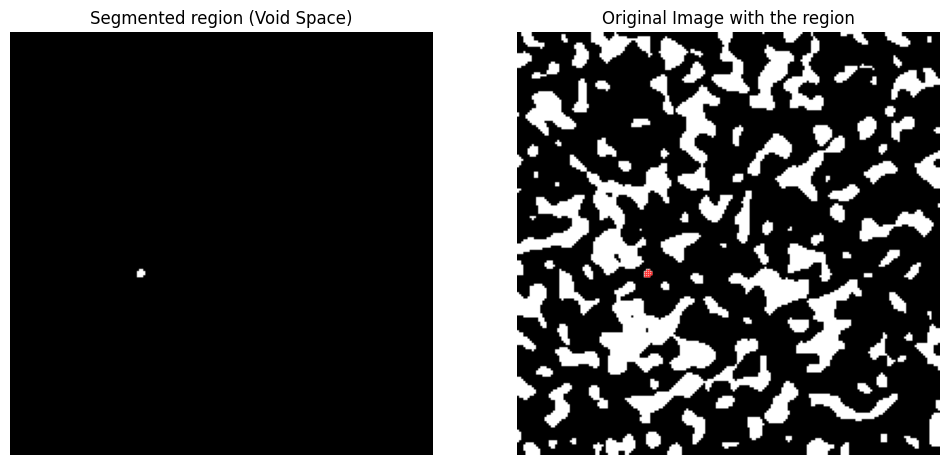

In [5]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [7]:
# The number of pixels to consider a pore
pore_number = 30

In [8]:
distancia_maxima= pore_number * 0.20
distancia_maxima

6.0

In [9]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas



# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [10]:
len(resultados_kmeans), len(contour_per_cluster)

(131, 131)

Random number_kmean: 22 175 number_of_pores 5


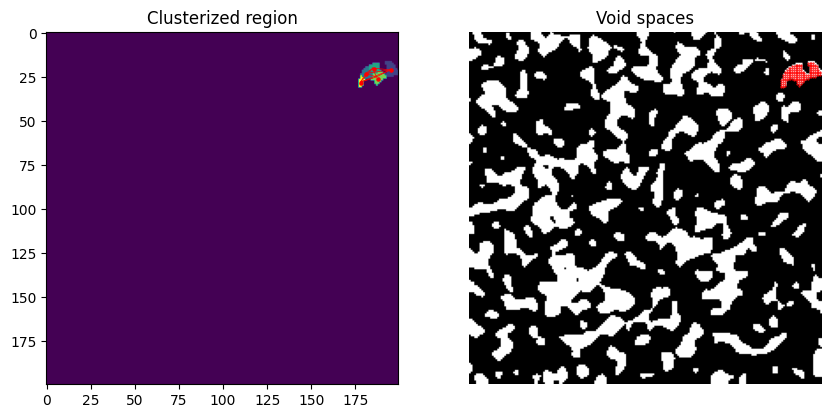

Número de ligações: 10


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, label

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, len(resultados_kmeans) - 1)
random_number_kmean = random_index
numero_de_elementos_na_região = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_index])

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Binarizar a imagem se necessário
binary_image = (regiao_aleatoria > 0).astype(int)

# Converte centros para inteiros
centros = [(int(centro[0]), int(centro[1])) for centro in centros]

# Aplicar dilatação até que os clusters estejam conectados
dilated_image = binary_image.copy()
numero_de_ligacoes = 0
conectados = False

while not conectados:
    dilated_image = binary_dilation(dilated_image)
    labeled_image, num_features = label(dilated_image)
    conectados = True
    for i in range(len(centros)):
        for j in range(i + 1, len(centros)):
            if labeled_image[centros[i][0], centros[i][1]] != labeled_image[centros[j][0], centros[j][1]]:
                conectados = False
            else:
                plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
                numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()
# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)
